In [1]:
# =========================
# Stage-1 Notebook v2
# Cell v2-01: Setup & Paths
# =========================
import os, json
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

SCENARIO_DIR = "/kaggle/input/uav-dataset/UAV DATASET/UAVBench_scenarios/UAVBench_scenarios/scenario_jsons"
assert os.path.exists(SCENARIO_DIR), f"Directory not found: {SCENARIO_DIR}"

files = sorted([f for f in os.listdir(SCENARIO_DIR) if f.lower().endswith(".json")])
print(f"✅ Found {len(files)} JSON scenario files.")


✅ Found 57248 JSON scenario files.


In [2]:
# =========================
# Cell v2-02: Feature Spec (Single Source of Truth)
# =========================

# 1) Raw numeric keys we care about (from JSON)
RAW_NUMERIC_KEYS = [
    "uav.mass_kg",
    "uav.max_speed_mps",
    "uav.battery_model.hover_power_W",
    "environment.weather.wind_mps",
    "environment.weather.gust_mps",
    "environment.gnss_jam_dbm",
    "daa.sep_threshold_m",
    "daa.ttc_threshold_s",
    "airspace.altitude_agl_max_m",
]

# 2) Raw categorical keys
RAW_CATEG_KEYS = [
    "uav.type",
    "mission.type",
    "mission.pattern",
    "environment.weather.visibility",
]

# 3) Raw boolean-ish keys (tri-state handled later)
RAW_BOOL_KEYS = [
    "environment.gnss_multipath",
    "comms.uplink_ok",
    "comms.downlink_ok",
    "environment.em_interference",
    "mission.runway_required",
]

# 4) Sensors that we standardize
SENSOR_KEYS = ["lidar","radar","gnss","imu","camera_rgb","camera_thermal"]

# 5) Derived features (created in FE)
DERIVED_FEATURES = [
    "feat_mission_dist_m",
    "feat_mission_climb_m",
    "feat_mission_tortuosity",
    "feat_obstacle_count",
    "feat_obstacle_avg_speed",
    "feat_airspace_area_m2",
    "feat_obstacle_density_per_km2",
    "feat_weather_score",
    "feat_power_to_weight",
]

# 6) Data quality + missingness features
DQ_FEATURES = [
    "dq_core_present_pct",
    "dq_weather_present",
    "dq_uav_present",
    "dq_mission_present",
    "dq_comms_present",
    "dq_sensors_present_pct",
]

print("✅ Feature Spec Ready.")
print(f"Raw numeric: {len(RAW_NUMERIC_KEYS)}, Raw cat: {len(RAW_CATEG_KEYS)}, Raw bool: {len(RAW_BOOL_KEYS)}")
print(f"Derived: {len(DERIVED_FEATURES)}, DQ: {len(DQ_FEATURES)}")


✅ Feature Spec Ready.
Raw numeric: 9, Raw cat: 4, Raw bool: 5
Derived: 9, DQ: 6


In [3]:
# =========================
# Cell v2-03: JSON Helpers
# =========================

WEATHER_SEVERITY_MAP = {
    'clear': 0, 'sun': 0, 'good': 0,
    'cloudy': 1, 'overcast': 1,
    'fog': 2, 'haze': 2, 'mist': 2,
    'rain': 3, 'light_rain': 3,
    'heavy_rain': 4, 'snow': 4,
    'storm': 5, 'thunderstorm': 5, 'windy': 3
}

def safe_get(d: dict, key_path: str):
    """Get nested dict value by dot path. Returns None if missing."""
    cur = d
    for k in key_path.split("."):
        if isinstance(cur, dict) and k in cur:
            cur = cur[k]
        else:
            return None
    return cur

def to_float_or_nan(x):
    try:
        if x is None: 
            return np.nan
        if isinstance(x, bool):
            return float(int(x))
        return float(x)
    except:
        return np.nan

def tri_state_bool(value):
    """
    Returns (val01, missing_flag)
    - if value is True/False -> (1/0, 0)
    - if missing/None -> (0, 1)  # value defaulted but missing flag = 1
    """
    if value is None:
        return 0, 1
    if isinstance(value, bool):
        return (1 if value else 0), 0
    # sometimes stored as 0/1
    if str(value).strip() in ["0","1"]:
        return int(value), 0
    return 0, 1

def weather_score(weather_obj):
    if not isinstance(weather_obj, dict):
        return 0
    score = 0
    phenomena = weather_obj.get("phenomena", [])
    if isinstance(phenomena, list):
        for p in phenomena:
            score += WEATHER_SEVERITY_MAP.get(str(p).lower().strip(), 1)
    vis = str(weather_obj.get("visibility","")).lower()
    if "poor" in vis or "low" in vis:
        score += 2
    return score


In [4]:
# =========================
# Cell v2-04: Feature Engineering v2
# =========================

def mission_profile(waypoints):
    if not isinstance(waypoints, list) or len(waypoints) < 2:
        return 0.0, 0.0
    dist, climb = 0.0, 0.0
    try:
        prev = np.array(waypoints[0], dtype=float)
        for pt in waypoints[1:]:
            cur = np.array(pt, dtype=float)
            dist += float(np.linalg.norm(cur - prev))
            if len(cur) > 2 and len(prev) > 2:
                dz = cur[2] - prev[2]
                if dz > 0: climb += float(dz)
            prev = cur
    except:
        return 0.0, 0.0
    return round(dist,2), round(climb,2)

def tortuosity(waypoints):
    if not isinstance(waypoints, list) or len(waypoints) < 3:
        return 0.0
    try:
        pts = np.array([p[:3] for p in waypoints if isinstance(p, list) and len(p) >= 2], dtype=float)
        if len(pts) < 3:
            return 0.0
        vecs = pts[1:] - pts[:-1]
        total = 0.0
        for i in range(len(vecs)-1):
            v1, v2 = vecs[i], vecs[i+1]
            n1, n2 = np.linalg.norm(v1), np.linalg.norm(v2)
            if n1 == 0 or n2 == 0:
                continue
            cos_a = np.clip(np.dot(v1,v2)/(n1*n2), -1.0, 1.0)
            total += float(np.degrees(np.arccos(cos_a)))
        return round(total,2)
    except:
        return 0.0

def polygon_area(geofence):
    try:
        pts = []
        if isinstance(geofence, list) and len(geofence) > 0 and isinstance(geofence[0], dict):
            pts = geofence[0].get("points", [])
        elif isinstance(geofence, dict):
            pts = geofence.get("points", [])
        if not isinstance(pts, list) or len(pts) < 3:
            return np.nan
        x = np.array([p[0] for p in pts], dtype=float)
        y = np.array([p[1] for p in pts], dtype=float)
        return float(0.5 * np.abs(np.dot(x, np.roll(y,1)) - np.dot(y, np.roll(x,1))))
    except:
        return np.nan

def extract_row_v2(data: dict, filename: str):
    row = {"filename": filename}
    
    # --- targets (keep original names for training stage) ---
    row["label.risk_level"] = to_float_or_nan(safe_get(data, "label.risk_level"))
    row["label.risk_category"] = safe_get(data, "label.risk_category")
    
    # --- raw numeric ---
    for k in RAW_NUMERIC_KEYS:
        row[k] = to_float_or_nan(safe_get(data, k))
    
    # --- raw categorical ---
    for k in RAW_CATEG_KEYS:
        v = safe_get(data, k)
        row[k] = (str(v).lower().strip() if v is not None else np.nan)
    
    # --- raw boolean tri-state -> two cols لكل واحد ---
    for k in RAW_BOOL_KEYS:
        v01, miss = tri_state_bool(safe_get(data, k))
        row[k] = v01
        row[f"is_missing__{k}"] = miss
    
    # --- sensors tri-state ---
    sensors = safe_get(data, "uav.sensors")
    sensors = sensors if isinstance(sensors, dict) else {}
    present_cnt = 0
    for s in SENSOR_KEYS:
        v = sensors.get(s, None)
        v01, miss = tri_state_bool(v)
        row[f"has_{s}"] = v01
        row[f"is_missing__has_{s}"] = miss
        if miss == 0: 
            present_cnt += 1
    
    # --- derived physics/system features ---
    waypoints = safe_get(data, "mission.waypoints")
    dist, climb = mission_profile(waypoints)
    row["feat_mission_dist_m"] = dist
    row["feat_mission_climb_m"] = climb
    row["feat_mission_tortuosity"] = tortuosity(waypoints)

    obstacles = safe_get(data, "moving_obstacles")
    if not isinstance(obstacles, list):
        obstacles = []
    row["feat_obstacle_count"] = len(obstacles)
    speeds = []
    for o in obstacles:
        if isinstance(o, dict):
            vel = o.get("vel", [0,0,0])
            try:
                speeds.append(float(np.linalg.norm(np.array(vel, dtype=float))))
            except:
                pass
    row["feat_obstacle_avg_speed"] = float(np.mean(speeds)) if len(speeds) else 0.0

    geofence = safe_get(data, "airspace.geofence")
    area = polygon_area(geofence)
    row["feat_airspace_area_m2"] = area
    if area is None or pd.isna(area) or area <= 0:
        row["feat_obstacle_density_per_km2"] = np.nan
    else:
        row["feat_obstacle_density_per_km2"] = (len(obstacles) / area) * 1e6

    weather_obj = safe_get(data, "environment.weather")
    row["feat_weather_score"] = weather_score(weather_obj)

    mass = row.get("uav.mass_kg", np.nan)
    power = row.get("uav.battery_model.hover_power_W", np.nan)
    if pd.notna(mass) and mass > 0 and pd.notna(power):
        row["feat_power_to_weight"] = power / mass
    else:
        row["feat_power_to_weight"] = np.nan
    
    # --- data quality features ---
    core_keys = ["uav.mass_kg","mission.waypoints","environment.weather.wind_mps","environment.gnss_jam_dbm"]
    core_present = sum([1 for k in core_keys if safe_get(data, k) is not None])
    row["dq_core_present_pct"] = core_present / len(core_keys)

    row["dq_weather_present"] = 1.0 if isinstance(weather_obj, dict) and len(weather_obj) > 0 else 0.0
    row["dq_uav_present"] = 1.0 if isinstance(safe_get(data, "uav"), dict) else 0.0
    row["dq_mission_present"] = 1.0 if isinstance(safe_get(data, "mission"), dict) else 0.0
    row["dq_comms_present"] = 1.0 if isinstance(safe_get(data, "comms"), dict) else 0.0
    row["dq_sensors_present_pct"] = present_cnt / len(SENSOR_KEYS)

    return row

print("✅ Feature Engineering v2 Ready.")


✅ Feature Engineering v2 Ready.


In [5]:
# =========================
# Cell v2-05: Build Dataset v2
# =========================

OUTPUT_DATASET = "uav_stage1_v2_dataset.csv"

rows = []
bad_json = 0
missing_targets = 0

print(f"🚀 Building Stage-1 v2 dataset from {len(files)} files...")

for fname in tqdm(files, desc="Extracting features"):
    path = os.path.join(SCENARIO_DIR, fname)
    try:
        with open(path, "r", encoding="utf-8") as f:
            data = json.load(f)

        row = extract_row_v2(data, fname)

        # --- Basic target validity checks ---
        # risk_level must be numeric
        if pd.isna(row.get("label.risk_level", np.nan)):
            missing_targets += 1
            continue

        # risk_category must exist (if missing, we drop)
        if row.get("label.risk_category", None) is None or str(row["label.risk_category"]).strip() == "":
            missing_targets += 1
            continue

        rows.append(row)

    except Exception:
        bad_json += 1
        continue

df_v2 = pd.DataFrame(rows)

print("\n" + "="*80)
print("✅ Dataset v2 Built")
print("="*80)
print(f"Rows kept (valid targets): {len(df_v2):,}")
print(f"Dropped (missing targets): {missing_targets:,}")
print(f"Bad JSON / read errors:    {bad_json:,}")
print(f"Columns: {df_v2.shape[1]:,}")

# Save
df_v2.to_csv(OUTPUT_DATASET, index=False)
print(f"\n💾 Saved: {OUTPUT_DATASET}")

# Quick peek
display(df_v2.head(3))


🚀 Building Stage-1 v2 dataset from 57248 files...


Extracting features:   0%|          | 0/57248 [00:00<?, ?it/s]


✅ Dataset v2 Built
Rows kept (valid targets): 57,248
Dropped (missing targets): 0
Bad JSON / read errors:    0
Columns: 53

💾 Saved: uav_stage1_v2_dataset.csv


/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pan

,filename,label.risk_level,label.risk_category,uav.mass_kg,uav.max_speed_mps,uav.battery_model.hover_power_W,environment.weather.wind_mps,environment.weather.gust_mps,environment.gnss_jam_dbm,daa.sep_threshold_m,...,feat_airspace_area_m2,feat_obstacle_density_per_km2,feat_weather_score,feat_power_to_weight,dq_core_present_pct,dq_weather_present,dq_uav_present,dq_mission_present,dq_comms_present,dq_sensors_present_pct
0,Aerial_Mapping_Under_Hail_Conditions_73f5b3c0b...,3.0,High Risk,8.5,18.0,600.0,8.5,4.5,NaN,25.0,...,60000.0,16.666667,3,70.588235,0.75,1.0,1.0,1.0,1.0,1.0
1,Aerial_Mapping_in_Cold_Rural_Environment_d0d39...,2.0,Medium Risk,2.5,15.0,89.2,6.0,4.0,NaN,25.0,...,200000.0,5.000000,1,35.680000,0.75,1.0,1.0,1.0,1.0,1.0
2,Aerial_Mapping_in_Rural_Area_with_Lightning_Ri...,2.0,Medium Risk,5.2,25.0,335.4,8.0,4.0,NaN,50.0,...,800000.0,1.250000,1,64.500000,0.75,1.0,1.0,1.0,1.0,1.0


In [6]:
# =========================
# Cell v2-06: Sanity Checks
# =========================

print("\n" + "="*80)
print("🎯 Target Checks")
print("="*80)

print("Risk Category distribution:")
display(df_v2["label.risk_category"].value_counts().to_frame("count"))

print("\nRisk Level stats:")
display(df_v2["label.risk_level"].describe().to_frame().T)

print("\n" + "="*80)
print("🧪 Data Quality (DQ) Overview")
print("="*80)

dq_cols = [c for c in df_v2.columns if c.startswith("dq_")]
display(df_v2[dq_cols].describe().T)

print("\n" + "="*80)
print("🕳️ Missingness: Top 30 columns by missing %")
print("="*80)

miss_pct = df_v2.isna().mean().sort_values(ascending=False) * 100
miss_df = pd.DataFrame({"missing_pct": miss_pct.round(2), "col": miss_pct.index})
display(miss_df.head(30))

print("\n" + "="*80)
print("🔎 Quick check: Are we defaulting missing booleans too much?")
print("="*80)

miss_flag_cols = [c for c in df_v2.columns if c.startswith("is_missing__")]
if len(miss_flag_cols) > 0:
    miss_flags_summary = df_v2[miss_flag_cols].mean().sort_values(ascending=False).head(20)
    display(miss_flags_summary.to_frame("missing_flag_rate"))
else:
    print("No missing flag columns found (unexpected).")

print("\n✅ Sanity checks complete.")



🎯 Target Checks
Risk Category distribution:


,count
label.risk_category,
High Risk,47965
Medium Risk,8746
Low Risk,537



Risk Level stats:


,count,mean,std,min,25%,50%,75%,max
label.risk_level,57248.0,2.828466,0.401091,1.0,3.0,3.0,3.0,3.0



🧪 Data Quality (DQ) Overview


...


🕳️ Missingness: Top 30 columns by missing %


,missing_pct,col
environment.gnss_jam_dbm,37.78,environment.gnss_jam_dbm
environment.weather.gust_mps,0.48,environment.weather.gust_mps
environment.weather.visibility,0.43,environment.weather.visibility
mission.pattern,0.43,mission.pattern
mission.type,0.43,mission.type
daa.ttc_threshold_s,0.43,daa.ttc_threshold_s
daa.sep_threshold_m,0.43,daa.sep_threshold_m
environment.weather.wind_mps,0.43,environment.weather.wind_mps
has_camera_thermal,0.00,has_camera_thermal
feat_obstacle_avg_speed,0.00,feat_obstacle_avg_speed



🔎 Quick check: Are we defaulting missing booleans too much?


,missing_flag_rate
is_missing__environment.gnss_multipath,0.397726
is_missing__environment.em_interference,0.351768
is_missing__mission.runway_required,0.155988
is_missing__has_radar,0.013904
is_missing__has_camera_thermal,0.009223
is_missing__has_lidar,0.005380
is_missing__has_camera_rgb,0.004612
is_missing__comms.uplink_ok,0.004367
is_missing__comms.downlink_ok,0.004367
is_missing__has_gnss,0.004297



✅ Sanity checks complete.


In [7]:
# =========================
# Cell v2-07: Stratified Split (70 / 15 / 15)
# =========================

import pandas as pd
from sklearn.model_selection import train_test_split

DATA_PATH = "uav_stage1_v2_dataset.csv"
df = pd.read_csv(DATA_PATH)

TARGET_REG = "label.risk_level"
TARGET_CLF = "label.risk_category"

X = df.drop(columns=[TARGET_REG, TARGET_CLF])
y_reg = df[TARGET_REG]
y_clf = df[TARGET_CLF]

print(f"📊 Full dataset: {X.shape}")

# --- Split 1: Train+Val (85%) / Test (15%) ---
X_temp, X_test, y_reg_temp, y_reg_test, y_clf_temp, y_clf_test = train_test_split(
    X, y_reg, y_clf,
    test_size=0.15,
    random_state=42,
    stratify=y_clf
)

# --- Split 2: Train (70%) / Val (15%) ---
val_ratio_adjusted = 0.15 / 0.85

X_train, X_val, y_reg_train, y_reg_val, y_clf_train, y_clf_val = train_test_split(
    X_temp, y_reg_temp, y_clf_temp,
    test_size=val_ratio_adjusted,
    random_state=42,
    stratify=y_clf_temp
)

print("\n⚖️ Risk Category Distribution (%):")
dist = pd.DataFrame({
    "Train": y_clf_train.value_counts(normalize=True),
    "Val":   y_clf_val.value_counts(normalize=True),
    "Test":  y_clf_test.value_counts(normalize=True)
}).fillna(0)

display(dist.round(4))

print(f"\n✅ Sizes → Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")


📊 Full dataset: (57248, 51)

⚖️ Risk Category Distribution (%):


,Train,Val,Test
label.risk_category,,,
High Risk,0.8378,0.8379,0.8378
Medium Risk,0.1528,0.1528,0.1528
Low Risk,0.0094,0.0093,0.0094



✅ Sizes → Train: 40072, Val: 8588, Test: 8588


In [10]:
# =========================
# Cell v2-08: Preprocessor v2
# =========================

import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
import joblib


# -------------------------
# Column Groups
# -------------------------

log_cols = [
    "uav.mass_kg",
    "uav.battery_model.hover_power_W",
    "feat_mission_dist_m",
    "feat_mission_climb_m",
    "feat_airspace_area_m2",
    "feat_power_to_weight",
    "feat_obstacle_density_per_km2"
]

robust_cols = [
    "uav.max_speed_mps",
    "environment.weather.wind_mps",
    "environment.weather.gust_mps",
    "environment.gnss_jam_dbm",
    "daa.sep_threshold_m",
    "daa.ttc_threshold_s",
    "feat_weather_score",
    "feat_obstacle_avg_speed",
    "feat_mission_tortuosity"
]

binary_cols = [c for c in X_train.columns if c.startswith("has_") or c.startswith("is_missing__")]

dq_cols = [c for c in X_train.columns if c.startswith("dq_")]

cat_cols = [
    "mission.type",
    "mission.pattern",
    "environment.weather.visibility"
]

# Helper
def keep(cols): 
    return [c for c in cols if c in X_train.columns]

log_cols     = keep(log_cols)
robust_cols  = keep(robust_cols)
binary_cols  = keep(binary_cols)
dq_cols      = keep(dq_cols)
cat_cols     = keep(cat_cols)

# -------------------------
# Pipelines
# -------------------------
def to_string_safe(x):
    return x.astype(str)

pipe_log = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("log", FunctionTransformer(np.log1p)),
    ("scaler", RobustScaler())
])

pipe_robust = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

pipe_binary = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

pipe_cat = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("to_str", FunctionTransformer(to_string_safe, validate=False)),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False,
        min_frequency=500   # 🔑 protects memory
    ))
])

preprocessor_v2 = ColumnTransformer(
    transformers=[
        ("log", pipe_log, log_cols),
        ("robust", pipe_robust, robust_cols),
        ("binary", pipe_binary, binary_cols),
        ("dq", "passthrough", dq_cols),
        ("cat", pipe_cat, cat_cols)
    ],
    remainder="drop"
)

# -------------------------
# Fit on TRAIN ONLY
# -------------------------
print("🚀 Fitting Preprocessor v2 on TRAIN set...")
preprocessor_v2.fit(X_train)

# Transform
X_train_p = preprocessor_v2.transform(X_train)
X_val_p   = preprocessor_v2.transform(X_val)
X_test_p  = preprocessor_v2.transform(X_test)

print("✅ Transformation complete.")
print("Shapes:", X_train_p.shape, X_val_p.shape, X_test_p.shape)

# Save
joblib.dump(preprocessor_v2, "uav_stage1_preprocessor_v2.pkl")
print("💾 Saved: uav_stage1_preprocessor_v2.pkl")


🚀 Fitting Preprocessor v2 on TRAIN set...
✅ Transformation complete.
Shapes: (40072, 58) (8588, 58) (8588, 58)
💾 Saved: uav_stage1_preprocessor_v2.pkl


In [11]:
# =========================
# Cell v2-09: Modeling (XGBoost)
# =========================

import numpy as np
import pandas as pd
import joblib
from xgboost import XGBRegressor, XGBClassifier
from sklearn.metrics import mean_squared_error, f1_score, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight

# -------------------------
# Load Preprocessed Data
# -------------------------

X_train_p = X_train_p
X_val_p   = X_val_p
X_test_p  = X_test_p

y_train_reg = y_reg_train
y_val_reg   = y_reg_val
y_test_reg  = y_reg_test

y_train_clf = y_clf_train
y_val_clf   = y_clf_val
y_test_clf  = y_clf_test

# =========================================================
# 1️⃣ REGRESSION — Risk Level (1–3)
# =========================================================

print("\n📈 Training Regressor (Risk Level)...")

xgb_reg = XGBRegressor(
    n_estimators=1200,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50
)

xgb_reg.fit(
    X_train_p, y_train_reg,
    eval_set=[(X_val_p, y_val_reg)],
    verbose=False
)

# Evaluation
y_val_pred = xgb_reg.predict(X_val_p)
rmse = np.sqrt(mean_squared_error(y_val_reg, y_val_pred))

print(f"✅ Regressor RMSE (Val): {rmse:.4f}")

# Save
joblib.dump(xgb_reg, "xgb_reg_stage1_v2.pkl")
print("💾 Saved: xgb_reg_stage1_v2.pkl")

# =========================================================
# 2️⃣ CLASSIFICATION — Risk Category
# =========================================================

print("\n🗂️ Training Classifier (Risk Category)...")

# Encode labels
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train_clf)
y_val_enc   = le.transform(y_val_clf)
y_test_enc  = le.transform(y_test_clf)

print("Label Encoding:")
for i, c in enumerate(le.classes_):
    print(f"  {i} → {c}")

# Class weights (CRITICAL due to imbalance)
sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train_enc
)

xgb_clf = XGBClassifier(
    n_estimators=1200,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=len(le.classes_),
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50
)

xgb_clf.fit(
    X_train_p, y_train_enc,
    sample_weight=sample_weights,
    eval_set=[(X_val_p, y_val_enc)],
    verbose=False
)

# Evaluation
y_val_pred_enc = xgb_clf.predict(X_val_p)
y_val_pred_lbl = le.inverse_transform(y_val_pred_enc)

print("\n📊 Classification Report (VAL):")
print(classification_report(y_val_clf, y_val_pred_lbl, digits=4))

f1_macro = f1_score(y_val_clf, y_val_pred_lbl, average="macro")
print(f"✅ F1-macro (Val): {f1_macro:.4f}")

# Save
joblib.dump(xgb_clf, "xgb_clf_stage1_v2.pkl")
joblib.dump(le, "label_encoder_stage1_v2.pkl")

print("\n💾 Saved:")
print("  - xgb_clf_stage1_v2.pkl")
print("  - label_encoder_stage1_v2.pkl")



📈 Training Regressor (Risk Level)...
✅ Regressor RMSE (Val): 0.1718
💾 Saved: xgb_reg_stage1_v2.pkl

🗂️ Training Classifier (Risk Category)...
Label Encoding:
  0 → High Risk
  1 → Low Risk
  2 → Medium Risk

📊 Classification Report (VAL):
              precision    recall  f1-score   support

   High Risk     0.9978    0.9515    0.9741      7196
    Low Risk     0.9506    0.9625    0.9565        80
 Medium Risk     0.7872    0.9870    0.8759      1312

    accuracy                         0.9570      8588
   macro avg     0.9119    0.9670    0.9355      8588
weighted avg     0.9652    0.9570    0.9589      8588

✅ F1-macro (Val): 0.9355

💾 Saved:
  - xgb_clf_stage1_v2.pkl
  - label_encoder_stage1_v2.pkl


In [12]:
# =========================
# Cell v2-10: Final Test Evaluation
# =========================

from sklearn.metrics import mean_squared_error, classification_report, f1_score
import numpy as np

print("📦 Evaluating on TEST set...")

# ---------- Regression ----------
y_test_pred = xgb_reg.predict(X_test_p)
rmse_test = np.sqrt(mean_squared_error(y_test_reg, y_test_pred))
print(f"\n📈 Test RMSE (Risk Level): {rmse_test:.4f}")

# ---------- Classification ----------
y_test_pred_enc = xgb_clf.predict(X_test_p)
y_test_pred_lbl = le.inverse_transform(y_test_pred_enc)

print("\n📊 Classification Report (TEST):")
print(classification_report(y_test_clf, y_test_pred_lbl, digits=4))

f1_macro_test = f1_score(y_test_clf, y_test_pred_lbl, average="macro")
print(f"✅ F1-macro (TEST): {f1_macro_test:.4f}")


📦 Evaluating on TEST set...

📈 Test RMSE (Risk Level): 0.1777

📊 Classification Report (TEST):
              precision    recall  f1-score   support

   High Risk     0.9968    0.9444    0.9699      7195
    Low Risk     0.8876    0.9753    0.9294        81
 Medium Risk     0.7640    0.9794    0.8584      1312

    accuracy                         0.9500      8588
   macro avg     0.8828    0.9664    0.9192      8588
weighted avg     0.9602    0.9500    0.9525      8588

✅ F1-macro (TEST): 0.9192


In [17]:
def get_feature_names_from_column_transformer(ct):
    """
    Robust extraction of feature names from ColumnTransformer
    Supports Pipelines, OneHotEncoder, passthrough
    """
    feature_names = []

    for name, transformer, cols in ct.transformers_:
        if transformer == "drop":
            continue

        # -------------------------
        # Passthrough
        # -------------------------
        if transformer == "passthrough":
            feature_names.extend(cols)
            continue

        # -------------------------
        # Pipeline
        # -------------------------
        if isinstance(transformer, Pipeline):
            last_step = transformer.steps[-1][1]

            # OneHotEncoder case
            if hasattr(last_step, "get_feature_names_out"):
                names = last_step.get_feature_names_out(cols)
                feature_names.extend(names)

            # Scalers / Imputers / FunctionTransformers
            else:
                feature_names.extend(cols)

        # -------------------------
        # Direct transformer
        # -------------------------
        elif hasattr(transformer, "get_feature_names_out"):
            names = transformer.get_feature_names_out(cols)
            feature_names.extend(names)

        else:
            feature_names.extend(cols)

    return feature_names


In [19]:
feature_names = get_feature_names_from_column_transformer(preprocessor_v2)

print(f"Total features: {len(feature_names)}")
feature_names[:58]


Total features: 58


['uav.mass_kg',
 'uav.battery_model.hover_power_W',
 'feat_mission_dist_m',
 'feat_mission_climb_m',
 'feat_airspace_area_m2',
 'feat_power_to_weight',
 'feat_obstacle_density_per_km2',
 'uav.max_speed_mps',
 'environment.weather.wind_mps',
 'environment.weather.gust_mps',
 'environment.gnss_jam_dbm',
 'daa.sep_threshold_m',
 'daa.ttc_threshold_s',
 'feat_weather_score',
 'feat_obstacle_avg_speed',
 'feat_mission_tortuosity',
 'is_missing__environment.gnss_multipath',
 'is_missing__comms.uplink_ok',
 'is_missing__comms.downlink_ok',
 'is_missing__environment.em_interference',
 'is_missing__mission.runway_required',
 'has_lidar',
 'is_missing__has_lidar',
 'has_radar',
 'is_missing__has_radar',
 'has_gnss',
 'is_missing__has_gnss',
 'has_imu',
 'is_missing__has_imu',
 'has_camera_rgb',
 'is_missing__has_camera_rgb',
 'has_camera_thermal',
 'is_missing__has_camera_thermal',
 'dq_core_present_pct',
 'dq_weather_present',
 'dq_uav_present',
 'dq_mission_present',
 'dq_comms_present',
 'dq_

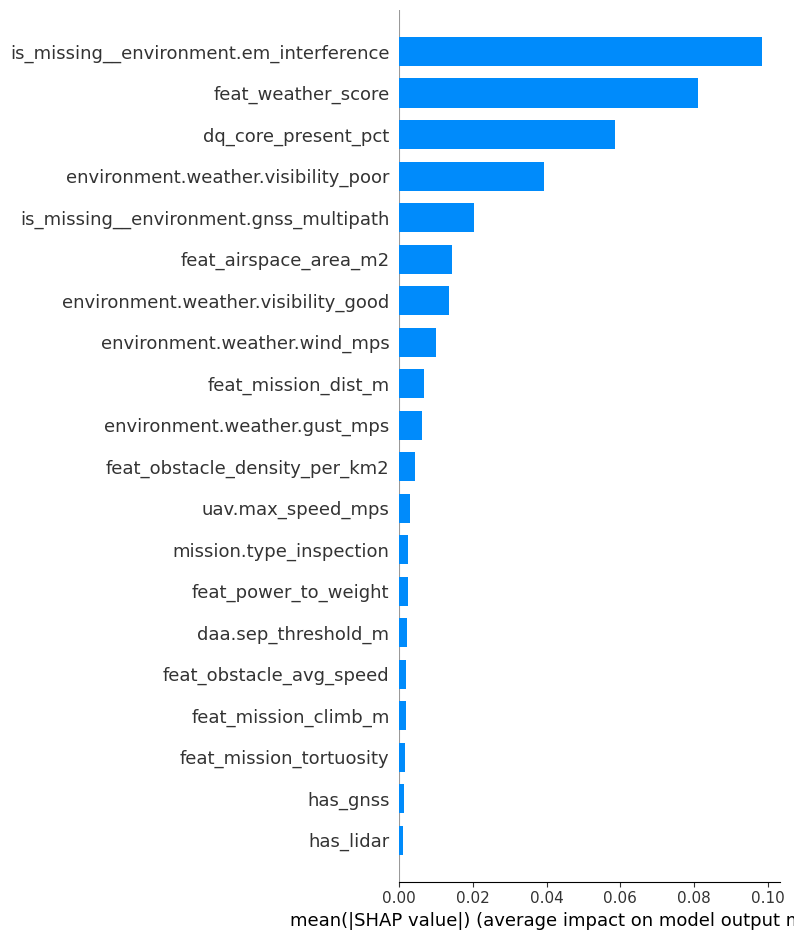

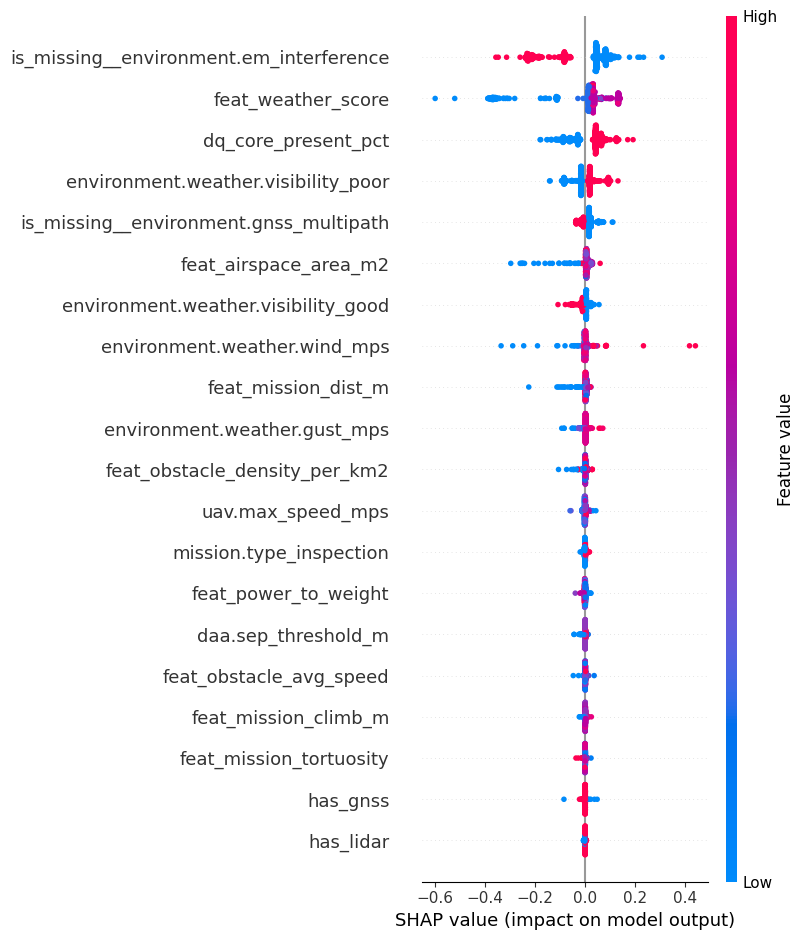

In [20]:
# =========================
# Cell v2-11: SHAP Explainability
# =========================
X_val_shap = pd.DataFrame(
    X_val_p,
    columns=feature_names
)

import shap

explainer = shap.TreeExplainer(xgb_reg)
shap_values = explainer.shap_values(X_val_shap.iloc[:500])

# Global importance
shap.summary_plot(
    shap_values,
    X_val_shap.iloc[:500],
    plot_type="bar"
)

# Directional impact
shap.summary_plot(
    shap_values,
    X_val_shap.iloc[:500]
)


In [14]:
# =========================
# Cell v2-12: Inference Engine
# =========================

import joblib
import numpy as np
import pandas as pd

class UAVRiskStage1V2:
    def __init__(self, models_dir="."):
        self.preprocessor = joblib.load(f"{models_dir}/uav_stage1_preprocessor_v2.pkl")
        self.reg = joblib.load(f"{models_dir}/xgb_reg_stage1_v2.pkl")
        self.clf = joblib.load(f"{models_dir}/xgb_clf_stage1_v2.pkl")
        self.le  = joblib.load(f"{models_dir}/label_encoder_stage1_v2.pkl")

    def predict(self, df_raw: pd.DataFrame):
        Xp = self.preprocessor.transform(df_raw)

        risk_level = float(self.reg.predict(Xp)[0])
        cls_idx = self.clf.predict(Xp)[0]
        cls_prob = self.clf.predict_proba(Xp)[0][cls_idx]

        return {
            "risk_level": round(risk_level, 3),
            "risk_category": self.le.inverse_transform([cls_idx])[0],
            "confidence_pct": round(cls_prob * 100, 1)
        }


In [21]:
import numpy as np

def get_feature_names_from_column_transformer(ct, input_features):
    """
    Returns output feature names for a fitted ColumnTransformer.
    Works even if inner pipelines don't implement get_feature_names_out,
    and handles OneHotEncoder names properly.
    """
    feature_names = []
    for name, trans, cols in ct.transformers_:
        if name == "remainder" and trans == "drop":
            continue

        # resolve columns (may be list of names or boolean mask)
        if isinstance(cols, (list, tuple)):
            used_cols = list(cols)
        elif hasattr(cols, "dtype") and cols.dtype == bool:
            used_cols = list(np.array(input_features)[cols])
        else:
            used_cols = list(cols) if cols is not None else []

        if trans == "passthrough":
            feature_names.extend(used_cols)
            continue

        # Pipeline case: take the last step for naming if available
        if hasattr(trans, "named_steps"):
            last_step = list(trans.named_steps.values())[-1]
            # If OneHotEncoder exists in pipeline, use it
            if "onehot" in trans.named_steps:
                ohe = trans.named_steps["onehot"]
                ohe_names = ohe.get_feature_names_out(used_cols)
                feature_names.extend(list(ohe_names))
            else:
                # no onehot: output dims = len(used_cols) typically
                feature_names.extend(used_cols)
            continue

        # Direct transformer case
        if hasattr(trans, "get_feature_names_out"):
            names = trans.get_feature_names_out(used_cols)
            feature_names.extend(list(names))
        else:
            feature_names.extend(used_cols)

    return feature_names

# بعد fit(preprocessor_v2)
feature_names = get_feature_names_from_column_transformer(preprocessor_v2, X_train.columns)
print("Output feature count:", len(feature_names))
print("First 20:", feature_names[:20])


Output feature count: 58
First 20: ['uav.mass_kg', 'uav.battery_model.hover_power_W', 'feat_mission_dist_m', 'feat_mission_climb_m', 'feat_airspace_area_m2', 'feat_power_to_weight', 'feat_obstacle_density_per_km2', 'uav.max_speed_mps', 'environment.weather.wind_mps', 'environment.weather.gust_mps', 'environment.gnss_jam_dbm', 'daa.sep_threshold_m', 'daa.ttc_threshold_s', 'feat_weather_score', 'feat_obstacle_avg_speed', 'feat_mission_tortuosity', 'is_missing__environment.gnss_multipath', 'is_missing__comms.uplink_ok', 'is_missing__comms.downlink_ok', 'is_missing__environment.em_interference']


In [23]:
import joblib
import numpy as np

# -------------------------
# Load label encoder
# -------------------------
le = joblib.load("/kaggle/working/label_encoder_stage1_v2.pkl")

# -------------------------
# Encode VAL labels (IMPORTANT)
# -------------------------
y_val_cat = le.transform(y_val_clf)

print("y_val_cat shape:", y_val_cat.shape)
print("Unique encoded labels:", np.unique(y_val_cat))


y_val_cat shape: (8588,)
Unique encoded labels: [0 1 2]


In [24]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import log_loss
import joblib
import numpy as np

# -------------------------
# Load base classifier
# -------------------------
base_clf = joblib.load("/kaggle/working/xgb_clf_stage1_v2.pkl")

# -------------------------
# Calibrator (ISOTONIC)
# -------------------------
calibrator = CalibratedClassifierCV(
    estimator=base_clf,
    method="isotonic",
    cv="prefit"
)

# -------------------------
# Fit on VAL only
# -------------------------
calibrator.fit(X_val_p, y_val_cat)

# -------------------------
# Before / After comparison
# -------------------------
proba_before = base_clf.predict_proba(X_val_p)
proba_after  = calibrator.predict_proba(X_val_p)

ll_before = log_loss(y_val_cat, proba_before, labels=[0,1,2])
ll_after  = log_loss(y_val_cat, proba_after,  labels=[0,1,2])

print("✅ Calibration completed")
print(f"LogLoss BEFORE: {ll_before:.4f}")
print(f"LogLoss AFTER : {ll_after:.4f}")

# -------------------------
# Save calibrator
# -------------------------
joblib.dump(calibrator, "/kaggle/working/clf_calibrator_stage1_v2.pkl")
print("💾 Saved: clf_calibrator_stage1_v2.pkl")


✅ Calibration completed
LogLoss BEFORE: 0.1156
LogLoss AFTER : 0.0888
💾 Saved: clf_calibrator_stage1_v2.pkl


In [25]:
import json
import numpy as np
import joblib

# Load calibrator
calibrator = joblib.load("/kaggle/working/clf_calibrator_stage1_v2.pkl")

# Calibrated probabilities on VAL
proba_val = calibrator.predict_proba(X_val_p)
conf_val = proba_val.max(axis=1)

# ======= Thresholds (مبنية على النتائج لديك) =======
POLICY = {
    # Data quality
    "min_dq_core_present": 0.75,

    # Confidence thresholds (بعد calibration)
    "min_confidence_any_decision": 0.55,
    "min_confidence_go": 0.80,

    # Class-specific handling
    "high_risk_confidence_no_go": 0.65,
    "low_risk_min_confidence": 0.60,

    # Meta
    "calibration": "isotonic",
    "notes": "Thresholds derived after calibration on validation set"
}

# Save policy
with open("/kaggle/working/stage1_policy_config_v2.json", "w") as f:
    json.dump(POLICY, f, indent=2)

print("💾 Saved: stage1_policy_config_v2.json")
print(json.dumps(POLICY, indent=2))


💾 Saved: stage1_policy_config_v2.json
{
  "min_dq_core_present": 0.75,
  "min_confidence_any_decision": 0.55,
  "min_confidence_go": 0.8,
  "high_risk_confidence_no_go": 0.65,
  "low_risk_min_confidence": 0.6,
  "calibration": "isotonic",
  "notes": "Thresholds derived after calibration on validation set"
}


In [26]:
import joblib
import json

bundle = {
    "version": "stage1_v2",
    "preprocessor": joblib.load("/kaggle/working/uav_stage1_preprocessor_v2.pkl"),
    "regressor": joblib.load("/kaggle/working/xgb_reg_stage1_v2.pkl"),
    "classifier": joblib.load("/kaggle/working/xgb_clf_stage1_v2.pkl"),
    "calibrator": joblib.load("/kaggle/working/clf_calibrator_stage1_v2.pkl"),
    "label_encoder": joblib.load("/kaggle/working/label_encoder_stage1_v2.pkl"),
    "feature_names": feature_names,
    "policy": json.load(open("/kaggle/working/stage1_policy_config_v2.json"))
}

joblib.dump(bundle, "/kaggle/working/stage1_bundle_v2.pkl")
print("💾 Saved: stage1_bundle_v2.pkl")


💾 Saved: stage1_bundle_v2.pkl


In [27]:
import numpy as np
import pandas as pd

def stage1_predict(bundle, X_raw_row: pd.DataFrame):
    """
    Input:
        X_raw_row: DataFrame (1 row) بنفس أعمدة التدريب قبل preprocessor
    Output:
        dict: decision + risk + confidence + reasoning
    """

    pre = bundle["preprocessor"]
    reg = bundle["regressor"]
    cal = bundle["calibrator"]
    le  = bundle["label_encoder"]
    policy = bundle["policy"]

    # -------- Gate 1: Data Quality --------
    dq_core = float(
        X_raw_row.get("dq_core_present_pct", pd.Series([1.0])).iloc[0]
    )

    if dq_core < policy["min_dq_core_present"]:
        return {
            "status": "INSUFFICIENT_DATA",
            "reason": f"Data quality too low (dq_core_present_pct={dq_core:.2f})",
            "risk_level": None,
            "risk_category": None,
            "confidence": None
        }

    # -------- Transform --------
    Xp = pre.transform(X_raw_row)

    # -------- ML Prediction --------
    risk_level = float(reg.predict(Xp)[0])
    proba = cal.predict_proba(Xp)[0]
    conf = float(np.max(proba))

    pred_class = int(np.argmax(proba))
    pred_label = le.inverse_transform([pred_class])[0]

    # -------- Gate 2: Confidence --------
    if conf < policy["min_confidence_any_decision"]:
        return {
            "status": "CAUTION",
            "reason": f"Low confidence ({conf:.2f})",
            "risk_level": risk_level,
            "risk_category": pred_label,
            "confidence": conf
        }

    # -------- Decision Policy --------
    if pred_label == "High Risk" and conf >= policy["high_risk_confidence_no_go"]:
        decision = "NO-GO"
        reason = "High Risk predicted with sufficient confidence"

    elif pred_label == "Medium Risk":
        decision = "GO WITH CAUTION"
        reason = "Medium Risk scenario"

    elif pred_label == "Low Risk" and conf >= policy["low_risk_min_confidence"]:
        decision = "GO"
        reason = "Low Risk predicted with sufficient confidence"

    else:
        decision = "CAUTION"
        reason = "Ambiguous risk / confidence borderline"

    return {
        "status": "OK",
        "decision": decision,
        "decision_reason": reason,
        "risk_level": round(risk_level, 3),
        "risk_category": pred_label,
        "confidence": round(conf, 3),
        "probabilities": {
            "High Risk": round(float(proba[0]), 3),
            "Low Risk": round(float(proba[1]), 3),
            "Medium Risk": round(float(proba[2]), 3)
        }
    }


In [32]:
import joblib

# -------------------------
# Load Stage-1 bundle
# -------------------------
bundle = joblib.load("/kaggle/working/stage1_bundle_v2.pkl")

# -------------------------
# اختر سيناريو واحد من Test
# (نفس الأعمدة قبل preprocessor)
# -------------------------
X_test_raw_sample = X_test.iloc[[4720]]  # أول سيناريو كمثال

# -------------------------
# Run Stage-1 inference
# -------------------------
result = stage1_predict(bundle, X_test_raw_sample)

print("📊 Stage-1 Result:")
for k, v in result.items():
    print(f"{k}: {v}")


📊 Stage-1 Result:
status: OK
decision: GO WITH CAUTION
decision_reason: Medium Risk scenario
risk_level: 2.061
risk_category: Medium Risk
confidence: 0.95
probabilities: {'High Risk': 0.05, 'Low Risk': 0.0, 'Medium Risk': 0.95}


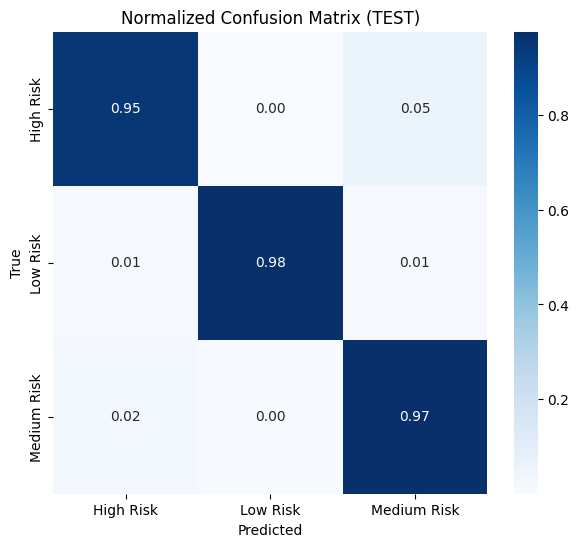

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# -------------------------
# Ground Truth (ENCODED)
# -------------------------
y_test_true = y_test_enc   # ✅ هذا هو الصحيح عندك

# -------------------------
# Predictions
# -------------------------
y_test_pred = calibrator.predict(X_test_p)

# -------------------------
# Confusion Matrix
# -------------------------
cm = confusion_matrix(
    y_test_true,
    y_test_pred,
    labels=[0, 1, 2]
)

# Normalize by true labels
cm_norm = cm / cm.sum(axis=1, keepdims=True)

labels = le.inverse_transform([0, 1, 2])

plt.figure(figsize=(7,6))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Normalized Confusion Matrix (TEST)")
plt.show()


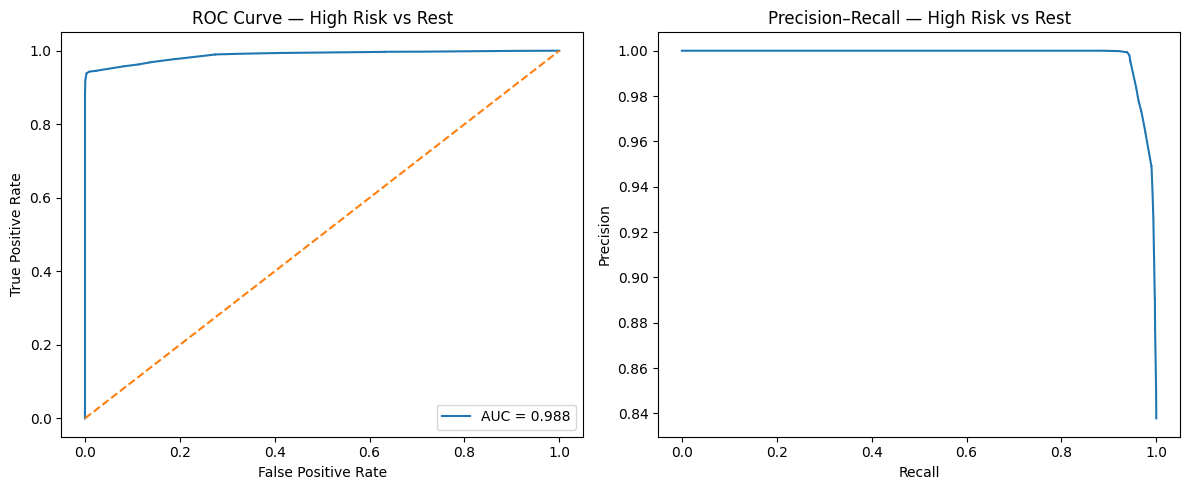

In [38]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve

# -------------------------
# Probabilities
# -------------------------
proba_test = calibrator.predict_proba(X_test_p)

# High Risk = class 0
y_true_high = (y_test_true == 0).astype(int)
y_score_high = proba_test[:, 0]

# -------------------------
# ROC
# -------------------------
fpr, tpr, _ = roc_curve(y_true_high, y_score_high)
roc_auc = auc(fpr, tpr)

# -------------------------
# Precision-Recall
# -------------------------
precision, recall, _ = precision_recall_curve(y_true_high, y_score_high)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — High Risk vs Rest")
plt.legend()

plt.subplot(1,2,2)
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall — High Risk vs Rest")

plt.tight_layout()
plt.show()


In [39]:
import pandas as pd
import numpy as np
from sklearn.metrics import precision_score, recall_score

thresholds = np.linspace(0.4, 0.9, 26)

records = []

proba_val = calibrator.predict_proba(X_val_p)
y_val_high = (y_val_cat == 0).astype(int)

for t in thresholds:
    pred_high = (proba_val[:,0] >= t).astype(int)
    
    prec = precision_score(y_val_high, pred_high, zero_division=0)
    rec  = recall_score(y_val_high, pred_high, zero_division=0)
    
    records.append({
        "threshold": t,
        "precision_high": prec,
        "recall_high": rec
    })

df_thr = pd.DataFrame(records)
df_thr.sort_values("threshold").head()


,threshold,precision_high,recall_high
0,0.40,0.966607,0.977487
1,0.42,0.966607,0.977487
2,0.44,0.981906,0.965258
3,0.46,0.997672,0.952752
4,0.48,0.997672,0.952752
